In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/malariaD.zip"

extract_path = "/content/cell_images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
print(os.listdir("/content/cell_images"))

['cell_images']


In [ ]:
print(os.listdir("/content/cell_images/cell_images"))

['cell_images', 'Parasitized', 'Uninfected']


In [ ]:
dataset_path = "/content/cell_images/cell_images/cell_images"

In [ ]:
print(os.listdir(dataset_path))

['Parasitized', 'Uninfected']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 85s 96ms/step - accuracy: 0.9110 - loss: 0.2354 - val_accuracy: 0.9267 - val_loss: 0.1999 - learning_rate: 0.0010
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 48s 70ms/step - accuracy: 0.9335 - loss: 0.1837 - val_accuracy: 0.9154 - val_loss: 0.2247 - learning_rate: 0.0010
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.9382 - loss: 0.1732 - val_accuracy: 0.9198 - val_loss: 0.2179 - learning_rate: 0.0010
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 51s 74ms/step - accuracy: 0.9472 - loss: 0.1523 - val_accuracy: 0.9316 - val_loss: 0.1807 - learning_rate: 2.0000e-04
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.9497 - loss: 0.1459 - val_accuracy: 0.9303 - val_loss: 0.1888 - learning_rate: 2.0000e-04
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 54s 78ms/step - accuracy: 0.9479 - loss: 0.1442 - val_accuracy: 0.9336 - val_loss: 0.1775 - learning_rate: 2.0000e-04
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 56s 82ms/step - accuracy

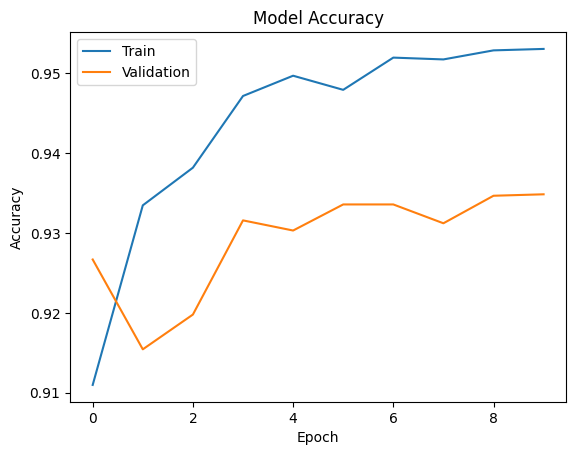

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

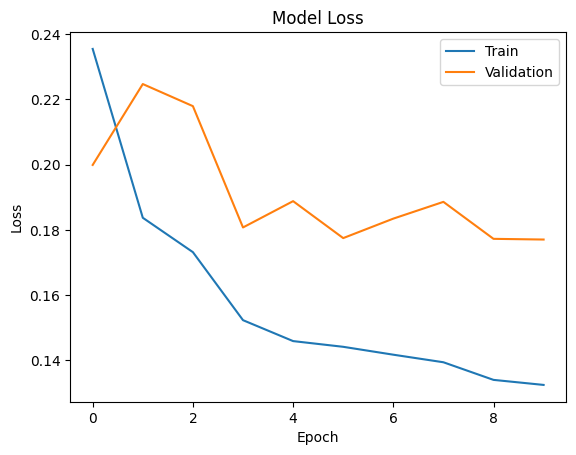

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

173/173 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.9348 - loss: 0.1770
Validation Accuracy: 0.9348457455635071
Validation Loss: 0.17704401910305023


In [ ]:
from tensorflow.keras.preprocessing import image

img_path = dataset_path + "/Parasitized/C33P1thinF_IMG_20150619_114756a_cell_179.png"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
[[9.999881e-01 1.186671e-05]]


In [ ]:
model.save("/content/drive/MyDrive/malaria_model.h5")

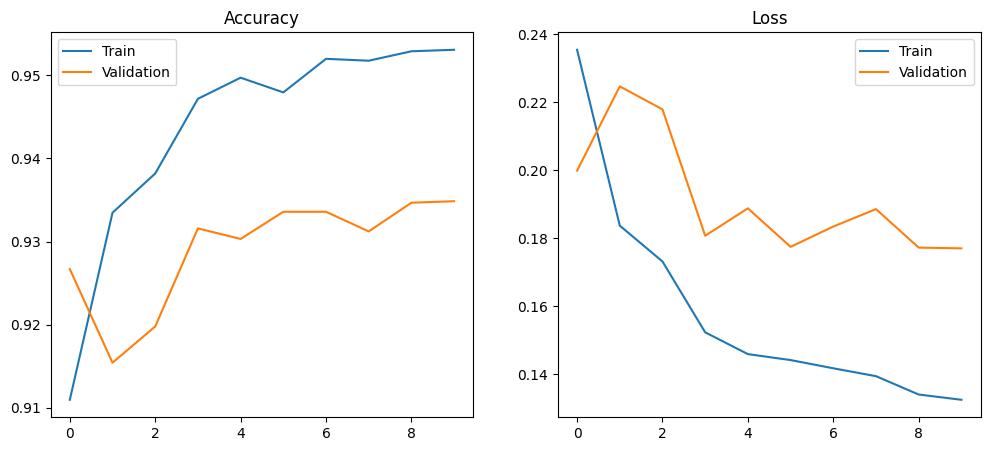

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 5510 images belonging to 2 classes.


In [ ]:
val_generator.reset()

In [ ]:
predictions = model.predict(val_generator)

173/173 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step


In [ ]:
import numpy as np

predicted_classes = np.argmax(predictions, axis=1)

In [ ]:
true_classes = val_generator.classes

In [ ]:
from sklearn.metrics import classification_report

class_labels = list(val_generator.class_indices.keys())

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

              precision    recall  f1-score   support

 Parasitized       0.94      0.93      0.93      2755
  Uninfected       0.93      0.94      0.94      2755

    accuracy                           0.93      5510
   macro avg       0.93      0.93      0.93      5510
weighted avg       0.93      0.93      0.93      5510



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

[[2566  189]
 [ 170 2585]]


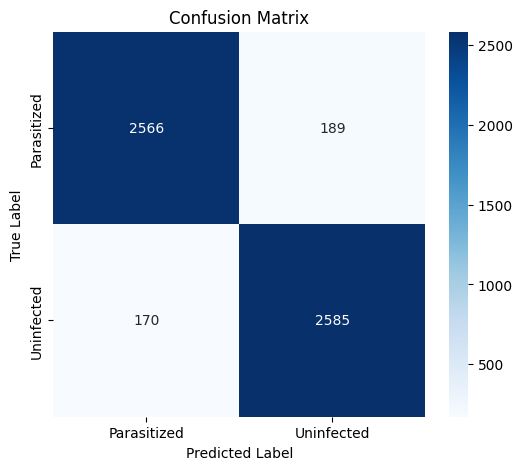

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Parasitized","Uninfected"],
            yticklabels=["Parasitized","Uninfected"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

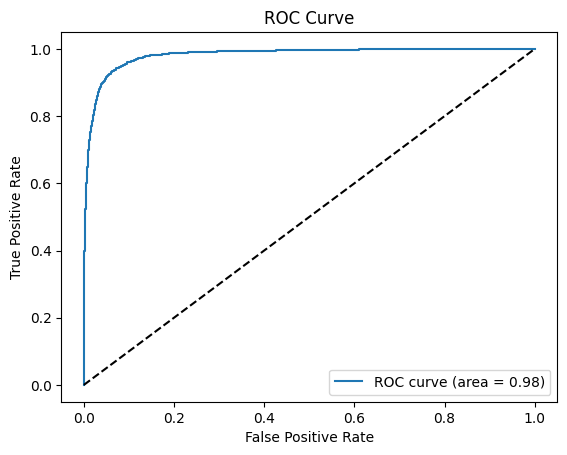

In [ ]:
from sklearn.metrics import roc_curve, auc

y_true = true_classes
y_pred_prob = predictions[:,1]

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

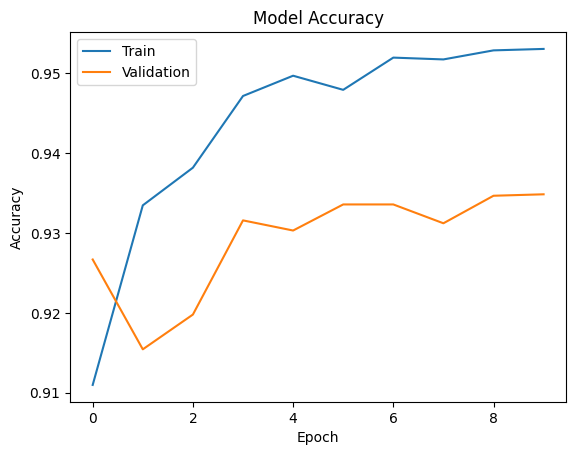

In [ ]:
plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.savefig("/content/drive/MyDrive/accuracy_graph.png")

plt.show()

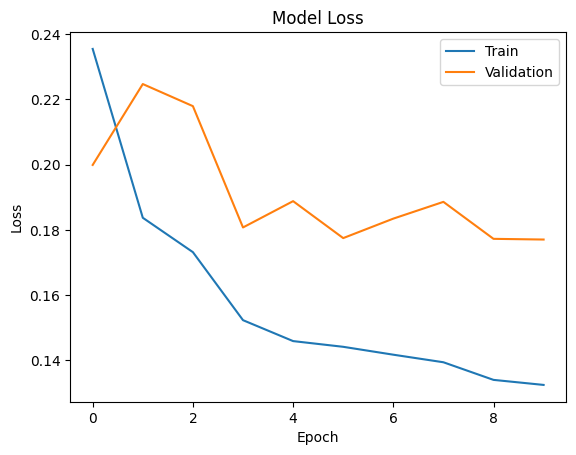

In [ ]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.savefig("/content/drive/MyDrive/loss_graph.png")

plt.show()

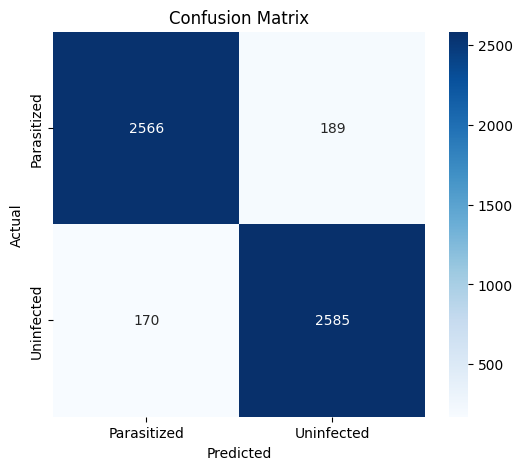

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Parasitized","Uninfected"],
    yticklabels=["Parasitized","Uninfected"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig("/content/drive/MyDrive/confusion_matrix.png")

plt.show()

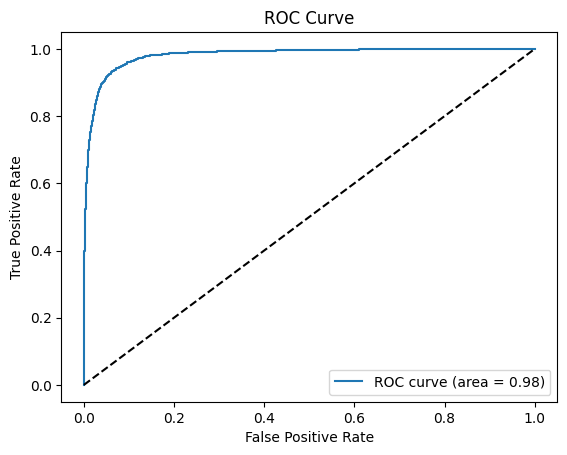

In [ ]:
from sklearn.metrics import roc_curve, auc

y_true = true_classes
y_pred_prob = predictions[:,1]

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.savefig("/content/drive/MyDrive/roc_curve.png")

plt.show()

In [ ]:
model.save("/content/drive/MyDrive/malaria_model2.h5")

In [ ]:
model.save("/content/drive/MyDrive/malaria_model3.keras")

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/malaria_model2.h5")

# Save again in clean format
model.save("/content/drive/MyDrive/malaria_model_fixed.h5")

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/malaria_model3.keras")

model.save("/content/drive/MyDrive/malaria_model_tf.h5", save_format="h5")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/malaria_model3.keras",
    compile=False
)

model.export("/content/drive/MyDrive/malaria_model_tf")

Saved artifact at '/content/drive/MyDrive/malaria_model_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137721351222672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137721270305232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137721270305424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137721270305808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137721270307152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137721270306576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137721270306000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137721270306960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137721270306768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137721270308112: TensorSpec(shape=(), dtype=tf.resource, name=

In [ ]:
model.save("malaria_model.keras")